<a href="https://colab.research.google.com/github/UW-CTRL/lmc-exercises/blob/main/exercises/03b_constraint_optimization_cvxpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `cvxpy`

In this problem we will explore the basics of `cvxpy`, a Python package for solving convex optimization problems. `cvxpy` has a good tutorial [here](https://www.cvxpy.org/tutorial/intro/index.html), so read that page before proceeding with this problem (the section on "parameters", while useful, is not important for this problem, so consider that section optional for now).

In [2]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

### Warm up


Consider the optimization problem for a vector variable $x = [x_1, x_2, x_3]^T$.  
Using `cvxpy`, find the minimizer of the following quadratic objective:
$$
\min_{x} \quad x_1^2 + 2x_2^2 + 3.5x_3^2
$$

subject to the linear inequality constraints:
$$
\begin{bmatrix}
0.707 & 0.707 & 0 \\
-1 & 0 & 0 \\
0 & -1 & 0 \\
0 & 0 & -1
\end{bmatrix}x \le
\begin{bmatrix}
2 \\
-1 \\
-1 \\
-3
\end{bmatrix}.
$$

Your task:
- Use `cvxpy` to set up and solve this problem.
- Print out the optimal vector $x$ and the minimized objective value.

This example illustrates how `cvxpy` streamlines the process of specifying and solving convex optimization problems, eliminating the need to implement custom algorithms by hand.

In [7]:
# TODO: Set up the problem and solve it
### add your code here
x = cp.Variable(3) # x is a 3D vecetor innit
obj_coeff_vec = np.array([1, 2, 3.5])
objective = cp.Minimize(x[0]**2 + 2*x[1]**2 + 3.5*x[2]**2)

mat =   np.array([
            [0.707, 0.707, 0],
            [-1, 0, 0],
            [0, -1, 0],
            [0, 0, -1] 
        ]) 
constraints = [mat@x <= np.array([2, -1, -1, -3])]
problem = cp.Problem(objective, constraints)
result = problem.solve()
###### end of add your code here


print(f"Optimal x: {x.value}")
print(f"Optimal objective value: {objective.value:.3f}")

Optimal x: [1. 1. 3.]
Optimal objective value: 34.500


### Resource allocation problem

Consider a simple **resource allocation** problem. We have 4 activities with costs $c = [2, 3, 1, 4]^T$ and we want to allocate a total budget of 1 unit across them. The "risk" (variance) of each activity is modeled by a quadratic form: we minimize $x^T Q x$ where $Q$ is the positive semidefinite matrix:
$$Q = \begin{bmatrix} 1 & 0.2 & 0 & 0.1 \\ 0.2 & 2 & 0.3 & 0 \\ 0 & 0.3 & 0.5 & 0.2 \\ 0.1 & 0 & 0.2 & 1.5 \end{bmatrix}.$$

**Problem**: Find $x \in \mathbb{R}^4$ that minimizes
$$x^T Q x + c^T x$$

subject to:
- **Equality constraint**: $\sum_{i=1}^4 x_i = 1$ (total allocation sums to 1)
- **Inequality constraints**: $x \ge 0$ (nonnegative allocations)
- **Extra constraint**: $x_1 + x_2 \ge 0.3$ (at least 30% must go to the first two activities)

Your task: Set up and solve this problem using `cvxpy`. Use `cp.quad_form(x, Q)` for the quadratic term. Print the optimal $x$ and the optimal objective value.

In [8]:
# TODO: Set up and solve the resource allocation problem
### add your code here
x = cp.Variable(4)
Q = np.array([
    [1, 0.2, 0, 0.1],
    [0.2, 2, 0.3, 0],
    [0, 0.3, 0.5, 0.2],
    [0.1, 0, 0.2, 1.5]
])

# cp.quad_form(x, Q) --> x.T @ Q @ x

c = np.array([2,3,1,4])
objective = cp.Minimize(cp.quad_form(x, Q)  +  c.T @ x)
constraints = [cp.sum(x) == 1, x >= 0, x[0] + x[1] >= 0.3]
problem = cp.Problem(objective, constraints)
problem.solve()
###### end of add your code here


print(f"Optimal x: {x.value}")
print(f"Optimal objective value: {objective.value:.4f}")

Optimal x: [3.00000000e-01 6.51825154e-23 7.00000000e-01 1.68777596e-22]
Optimal objective value: 1.6350


### Simple planning problem

Consider a discrete-time **double integrator**: state $x_t = [p_t, v_t]^T \in \mathbb{R}^2$ (position and velocity) and control $u_t \in \mathbb{R}$ (acceleration). The dynamics are
$$
x_{t+1} = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix} x_t + \begin{bmatrix} 0 \\ 1 \end{bmatrix} u_t
\quad\Rightarrow\quad
p_{t+1} = p_t + v_t,\quad v_{t+1} = v_t + u_t.
$$
We plan over horizon $T = 6$ starting from $x_0 = [0, 0]^T$ (at rest at the origin).

**Goal**: Minimize control effort while reaching near $p_T = 1$ with zero velocity, i.e. minimize
$$\sum_{t=0}^{T-1} u_t^2 + 10\,(p_T - 1)^2 + 5\,v_T^2.$$

**Constraints**:
- **Dynamics**: $x_{t+1} = A x_t + B u_t$ for $t = 0, \ldots, T-1$ (with $A$, $B$ above)
- **Initial condition**: $x_0 = [0, 0]^T$
- **State bounds**: $0 \le p_t \le 2$, $|v_t| \le 1$ for all $t$
- **Control bounds**: $|u_t| \le 0.8$ for all $t$

Your task: Set up and solve this planning problem in `cvxpy`. Use a 2D variable for the state sequence (e.g., `x` of shape $(2, T+1)$ so `x[0,t]` is position and `x[1,t]` is velocity). Print the optimal state trajectory, control sequence, and objective value.

Optimal state trajectory (position, velocity):
[[-1.24831455e-11 -1.30563782e-11  1.41832181e-01  3.69075389e-01
   6.25308472e-01  8.54110276e-01  9.99059648e-01]
 [ 9.28316179e-12  1.41832181e-01  2.27243208e-01  2.56233083e-01
   2.28801804e-01  1.44949372e-01  4.67578625e-03]]
Optimal control sequence: [ 0.14183218  0.08541103  0.02898987 -0.02743128 -0.08385243 -0.14027359]
Problem Status: optimal
Objective value: 0.0564


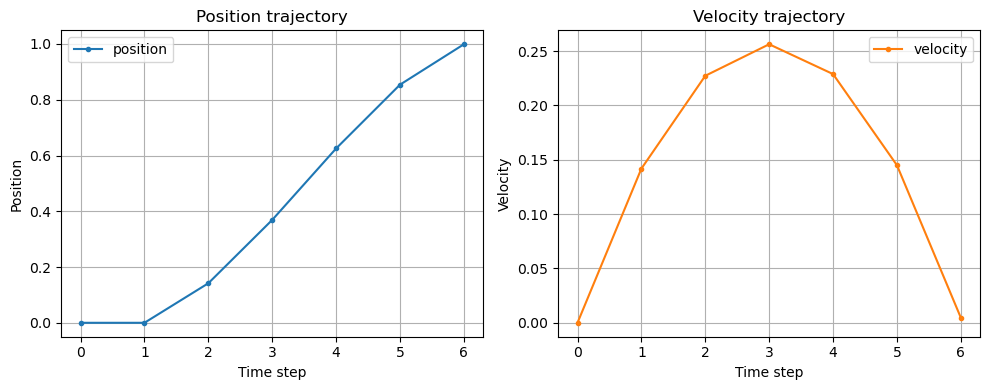

In [22]:
# TODO: Set up and solve the planning problem
T = 6
x0 = np.array([0.0, 0.0])  # [position, velocity]
A = np.array([[1, 1], [0, 1]])
B = np.array([0.0, 1.0])  # B @ u gives (2,) for scalar u
### add your code here
x = cp.Variable((2,T+1))
u = cp.Variable(T)
dynamics = [x[:,t+1] == A@x[:,t] + B*u[t] for t in range(T)]
initial_cond = x[:,0] == x0
state_bounds = [x[0,:] >= 0, x[0,:] <= 2, cp.abs(x[1,:]) <= 1]
control_bounds = cp.abs(u) <= 0.8
objective = cp.Minimize(cp.sum(u**2 + 10*(x[0,-1] - 1)**2 + 5*x[1,-1]**2))
constraints = [*dynamics, initial_cond, *state_bounds, control_bounds]
problem = cp.Problem(objective, constraints)
problem.solve()
###### end of add your code here


print(f"Optimal state trajectory (position, velocity):\n{x.value}")
print(f"Optimal control sequence: {u.value}")
print(f"Problem Status: {problem.status}")
print(f"Objective value: {objective.value:.4f}")
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(x.value[0, :], ".-", label="position")
ax[0].set_xlabel("Time step")
ax[0].set_ylabel("Position")
ax[0].set_title("Position trajectory")
ax[0].grid()
ax[0].legend()
ax[1].plot(x.value[1, :], ".-", label="velocity", color="C1")
ax[1].set_xlabel("Time step")
ax[1].set_ylabel("Velocity")
ax[1].set_title("Velocity trajectory")
ax[1].grid()
ax[1].legend()
plt.tight_layout()
plt.show()
